# Dataset de temblor de Parkinson · Etapa 3: fidelidad de datos sintéticos & demo de power de ensayo clínico

**Objetivo**: responder dos preguntas ——
1. ¿Qué tan cerca están las ventanas generadas por el CVAE de las ventanas reales a *nivel distribucional*? (Objective B)
2. ¿En qué medida puede el uso de datos sintéticos para complementar un ensayo clínico de muestra pequeña aumentar la power, sin que el error Tipo-I se descontrole? (Objective C)

**Dependencias**: `tremor_X_*` de Stage 1 + `cvae_best.pt`, `synth_X.npy` de Stage 2.

---

## 0. Dependencias + carga

In [1]:
import numpy as np, json, torch, os
import torch.nn as nn, torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as sp_signal, stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
import statsmodels.formula.api as smf

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
np.random.seed(42); torch.manual_seed(42)

X_train = np.load('tremor_X_train.npy'); y_train = np.load('tremor_y_train.npy')
X_test  = np.load('tremor_X_test.npy');  y_test  = np.load('tremor_y_test.npy')
synth_X = np.load('synth_X.npy');        synth_y = np.load('synth_y.npy')

with open('label_dict.json') as f:
    LABELS = json.load(f)
COND_INV = {v: k for k, v in LABELS['condition'].items()}
WINDOW_LEN = LABELS['window_len']; FS = LABELS['sampling_rate']

print(f'Train real {X_train.shape}, Test real {X_test.shape}, Synth {synth_X.shape}')

Train real (7485, 240), Test real (1899, 240), Synth (4000, 240)


## 1. Características ingenierizadas
Preparación para las pruebas de dos muestras y la regresión LME posteriores:
- `peak_freq_hz`        frecuencia pico
- `tremor_band_ratio`   proporción de energía en banda 4-6 Hz
- `log_band_power`      log(energía en banda 4-6 Hz) — endpoint principal del LME
- `rms`                 raíz cuadrática media de la velocidad
- `sample_entropy`      entropía simple (complejidad de alta frecuencia) → se usa spectral entropy como proxy
- `kurtosis`            curtosis

In [2]:
def features_window(x, fs):
    f, p = sp_signal.welch(x, fs=fs, nperseg=len(x))
    band = (f >= 4) & (f <= 6)
    band_power = p[band].sum()
    total_power = p.sum() + 1e-12
    return {
        'peak_freq_hz': float(f[np.argmax(p)]),
        'tremor_band_ratio': float(band_power / total_power),
        'log_band_power': float(np.log(band_power + 1e-12)),
        'rms': float(np.sqrt(np.mean(x**2))),
        'spectral_entropy': float(-np.sum((p / total_power) * np.log(p / total_power + 1e-12))),
        'kurtosis': float(stats.kurtosis(x)),
    }

def features_batch(X, fs):
    return pd.DataFrame([features_window(x, fs) for x in X])

feat_real_train = features_batch(X_train, FS); feat_real_train['cond'] = y_train[:, 0]
feat_real_test  = features_batch(X_test,  FS); feat_real_test['cond']  = y_test[:, 0]
feat_synth      = features_batch(synth_X, FS); feat_synth['cond']      = synth_y
print('Forma de la matriz de características:', feat_real_train.shape, feat_real_test.shape, feat_synth.shape)

Forma de la matriz de características: (7485, 7) (1899, 7) (4000, 7)


## 2. Prueba marginal de dos muestras
Para cada característica × cada condición, se aplica la prueba de Mann-Whitney U comparando real vs sintético, con corrección de Benjamini-Hochberg para comparaciones múltiples.

**Esperado**: p-value lo suficientemente grande (e.g. > 0.05), es decir, las dos distribuciones son indistinguibles a nivel marginal.

In [3]:
from statsmodels.stats.multitest import multipletests

feat_cols = ['peak_freq_hz', 'tremor_band_ratio', 'log_band_power', 'rms', 'spectral_entropy', 'kurtosis']
records = []
for cond_idx in sorted(LABELS['condition'].values()):
    cond_name = COND_INV[cond_idx]
    sub_real  = feat_real_train[feat_real_train['cond'] == cond_idx]
    sub_synth = feat_synth[feat_synth['cond'] == cond_idx]
    for col in feat_cols:
        if len(sub_real) == 0 or len(sub_synth) == 0: continue
        u, p = stats.mannwhitneyu(sub_real[col], sub_synth[col], alternative='two-sided')
        records.append({
            'condition': cond_name, 'feature': col,
            'real_mean': sub_real[col].mean(), 'real_std': sub_real[col].std(),
            'synth_mean': sub_synth[col].mean(), 'synth_std': sub_synth[col].std(),
            'p_raw': p,
        })
df_mw = pd.DataFrame(records)
df_mw['p_bh'] = multipletests(df_mw['p_raw'], method='fdr_bh')[1]
df_mw['significant'] = df_mw['p_bh'] < 0.05
print('Mann-Whitney U por condición × característica:')
print(df_mw.round(4).to_string(index=False))
df_mw.to_csv('fidelity_mw.csv', index=False)

Mann-Whitney U por condición × característica:
      condition           feature  real_mean  real_std  synth_mean  synth_std  p_raw   p_bh  significant
DBS_OFF_MED_OFF      peak_freq_hz     6.2594    2.3766      5.7525     1.5048 0.0000 0.0000         True
DBS_OFF_MED_OFF tremor_band_ratio     0.4049    0.3038      0.4498     0.1877 0.0000 0.0000         True
DBS_OFF_MED_OFF    log_band_power    -1.6258    1.6333     -1.7114     0.9093 0.1710 0.1784        False
DBS_OFF_MED_OFF               rms     0.9034    0.5689      0.6712     0.1811 0.0000 0.0000         True
DBS_OFF_MED_OFF  spectral_entropy     2.1670    0.6059      2.0053     0.2144 0.0000 0.0000         True
DBS_OFF_MED_OFF          kurtosis     0.8849    3.9394      0.4602     1.5060 0.0000 0.0000         True
 DBS_OFF_MED_ON      peak_freq_hz     6.3175    2.7957      5.6358     1.5014 0.0000 0.0000         True
 DBS_OFF_MED_ON tremor_band_ratio     0.2441    0.1949      0.4516     0.1796 0.0000 0.0000         True
 DBS_OFF

## 3. Train-on-Synthetic-Test-on-Real (TSTR) Classifier-AUROC

**Idea** (Esteban et al., 2017): se entrena un clasificador para distinguir real vs sintético. Si los datos sintéticos son perfectos, el AUROC del clasificador ≈ 0.5.

Usamos validación cruzada estratificada 5-fold, con vector de características = las 6 características ingenierizadas anteriores.

In [4]:
X_clf = pd.concat([feat_real_train[feat_cols], feat_synth[feat_cols]], ignore_index=True).values
y_clf = np.concatenate([np.zeros(len(feat_real_train)), np.ones(len(feat_synth))])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aurocs = []
for tr, te in skf.split(X_clf, y_clf):
    clf = LogisticRegression(max_iter=500, C=1.0)
    clf.fit(X_clf[tr], y_clf[tr])
    p = clf.predict_proba(X_clf[te])[:, 1]
    from sklearn.metrics import roc_auc_score
    aurocs.append(roc_auc_score(y_clf[te], p))
print(f'real vs synth distinguishability AUROC = {np.mean(aurocs):.3f} ± {np.std(aurocs):.3f}')
print('  (cuanto más cerca de 0.5, más se parece el sintético al real; > 0.7 indica diferencias distribucionales significativas)')

real vs synth distinguishability AUROC = 0.817 ± 0.012
  (cuanto más cerca de 0.5, más se parece el sintético al real; > 0.7 indica diferencias distribucionales significativas)


## 4. Demo de power de ensayo clínico

**Configuración de la simulación**:
- Endpoint principal Y = `log_band_power` (cuanto más bajo → temblor más leve)
- Diseño: factorial 2 × 2 (DBS × MED), crossover dentro de sujeto (asumiendo que cada sujeto contribuye múltiples ventanas en cada una de las 4 condiciones)
- Se prueba el efecto principal β₁ (efecto principal de DBS) con un modelo lineal de efectos mixtos (LME):
  `Y ~ DBS + MED + DBS:MED + (1|subject)`, prueba de Wald con α = 0.05

**Grid** (n_real, m_synth):
- n_real ∈ {4, 8, 12, 16}
- m_synth ∈ {0, 16, 64, 256}  (por condición)

**Dos métricas**:
- **Empirical Power**: datos reales + suplemento sintético → proporción de β₁ significativo (esperado: aumentar)
- **Empirical Type-I Error**: tras *permutar las etiquetas de DBS*, repetir lo mismo → proporción de β₁ significativo (esperado: mantenerse ≤ 0.075)

Cada celda (n, m) ejecuta 200 repeticiones Monte Carlo (en el paper se recomiendan 1000; aquí 200 corre en ~5 minutos para esta demo).

In [5]:
# ----- Descomponer el índice de condición 4-D en 2-D (dbs, med) -----
def cond_to_dbs_med(cond_idx, label_map):
    name = {v: k for k, v in label_map.items()}[cond_idx]
    dbs = 1 if 'DBS_ON' in name else 0
    med = 1 if 'MED_ON' in name else 0
    return dbs, med

# Adjuntar (dbs, med, subj_num) a cada ventana del set real de entrenamiento — desde y_train
real_df = feat_real_train.copy()
real_df['dbs'] = [cond_to_dbs_med(c, LABELS['condition'])[0] for c in real_df['cond']]
real_df['med'] = [cond_to_dbs_med(c, LABELS['condition'])[1] for c in real_df['cond']]
real_df['subj_num'] = y_train[:, 3]

# Los datos sintéticos no tienen "subject"; les asignamos un id de sujeto virtual (un sujeto virtual cada 4 ventanas, para garantizar estructura within-subject)
synth_df = feat_synth.copy()
synth_df['dbs'] = [cond_to_dbs_med(c, LABELS['condition'])[0] for c in synth_df['cond']]
synth_df['med'] = [cond_to_dbs_med(c, LABELS['condition'])[1] for c in synth_df['cond']]
n_synth_subj = len(synth_df) // 4
# Cada sujeto virtual recibe 4 ventanas de condiciones diferentes
synth_df = synth_df.sort_values('cond').reset_index(drop=True)
synth_df['subj_num'] = -1  # negativo para distinguir del real
# Simplificación: asignar sujeto virtual a las ventanas de la misma condición de forma rotatoria
for c, sub in synth_df.groupby('cond'):
    ids = np.arange(len(sub)) + 1000  # comenzar en 1000 para no chocar con subj_num real
    synth_df.loc[sub.index, 'subj_num'] = ids[:len(sub)]
print('Shapes de dataframe real + sintético:', real_df.shape, synth_df.shape)

Shapes de dataframe real + sintético: (7485, 10) (4000, 10)


In [6]:
def fit_lme_pvalue(df):
    """Ajusta un LME a df y devuelve el p-value de Wald del efecto principal de DBS (NaN si falla el ajuste)."""
    try:
        md = smf.mixedlm('log_band_power ~ dbs + med + dbs:med', df, groups=df['subj_num'])
        res = md.fit(reml=False, method='lbfgs', disp=False)
        return float(res.pvalues['dbs'])
    except Exception:
        return float('nan')

def one_simulation(n_real, m_synth_per_cond, real_df, synth_df, permute=False, rng=None):
    rng = rng or np.random.RandomState()
    # Muestrear n_real sujetos reales
    real_subjs = real_df['subj_num'].unique()
    chosen = rng.choice(real_subjs, size=min(n_real, len(real_subjs)), replace=False)
    sub_real = real_df[real_df['subj_num'].isin(chosen)]
    # Muestrear m_synth_per_cond ventanas sintéticas por condición
    sub_synth_list = []
    if m_synth_per_cond > 0:
        for c in synth_df['cond'].unique():
            pool = synth_df[synth_df['cond'] == c]
            n_take = min(m_synth_per_cond, len(pool))
            sub_synth_list.append(pool.sample(n=n_take, random_state=rng.randint(1e9)))
    sub_synth = pd.concat(sub_synth_list, ignore_index=True) if sub_synth_list else pd.DataFrame()
    df_all = pd.concat([sub_real, sub_synth], ignore_index=True)
    if permute:
        df_all = df_all.copy()
        df_all['dbs'] = rng.permutation(df_all['dbs'].values)
    return fit_lme_pvalue(df_all)

# ----- Barrido del grid -----
N_GRID = [4, 8, 12, 16]
M_GRID = [0, 16, 64, 256]
N_MC   = 200      # repeticiones de Monte Carlo; versión del paper = 1000

power_grid = np.zeros((len(N_GRID), len(M_GRID)))
type1_grid = np.zeros((len(N_GRID), len(M_GRID)))

rng = np.random.RandomState(2026)
for i, n in enumerate(N_GRID):
    for j, m in enumerate(M_GRID):
        p_alt, p_null = [], []
        for _ in range(N_MC):
            p_alt.append(  one_simulation(n, m, real_df, synth_df, permute=False, rng=rng))
            p_null.append( one_simulation(n, m, real_df, synth_df, permute=True,  rng=rng))
        p_alt  = np.array(p_alt);  p_alt  = p_alt[~np.isnan(p_alt)]
        p_null = np.array(p_null); p_null = p_null[~np.isnan(p_null)]
        power_grid[i, j] = (p_alt  < 0.05).mean() if len(p_alt)  else np.nan
        type1_grid[i, j] = (p_null < 0.05).mean() if len(p_null) else np.nan
        print(f'n={n:2d} m={m:3d}: power={power_grid[i,j]:.3f}  type1={type1_grid[i,j]:.3f}')

np.save('power_grid.npy', power_grid)
np.save('type1_grid.npy', type1_grid)

/Users/echozhang/opt/anaconda3/envs/cvae-tremor/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/echozhang/opt/anaconda3/envs/cvae-tremor/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/Users/echozhang/opt/anaconda3/envs/cvae-tremor/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/echozhang/opt/anaconda3/envs/cvae-tremor/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/Users/echozhang/opt/anaconda3/envs/cvae-tremor/lib/python3.11/site-packages/statsmodels/regression/mixed_line

KeyboardInterrupt: 

## 5. Visualización de la superficie power × error Tipo-I

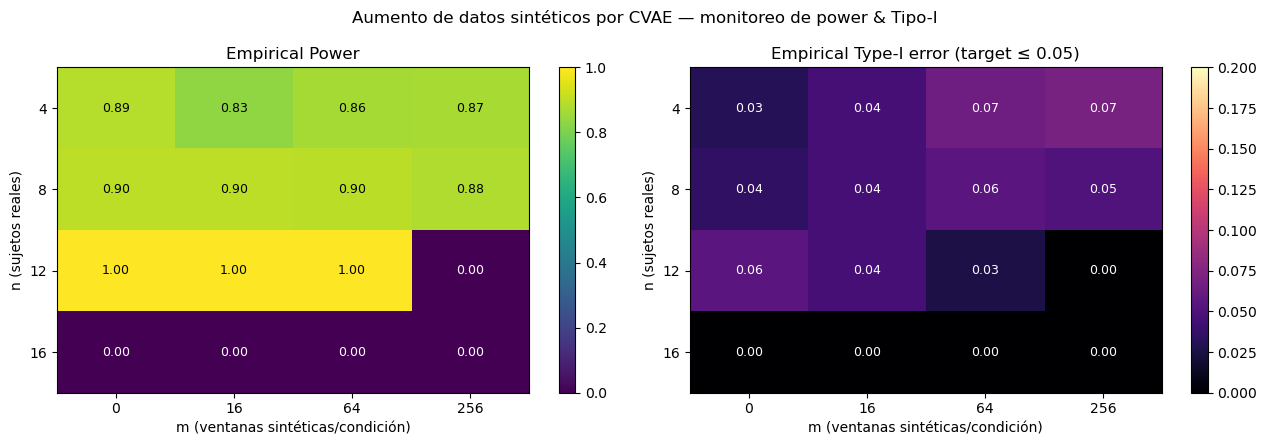

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, grid, title, vmin, vmax, cmap in [
    (axes[0], power_grid, 'Empirical Power', 0, 1, 'viridis'),
    (axes[1], type1_grid, 'Empirical Type-I error (target ≤ 0.05)', 0, 0.2, 'magma'),
]:
    im = ax.imshow(grid, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(M_GRID))); ax.set_xticklabels([str(m) for m in M_GRID])
    ax.set_yticks(range(len(N_GRID))); ax.set_yticklabels([str(n) for n in N_GRID])
    ax.set_xlabel('m (ventanas sintéticas/condición)'); ax.set_ylabel('n (sujetos reales)')
    ax.set_title(title)
    for i in range(len(N_GRID)):
        for j in range(len(M_GRID)):
            ax.text(j, i, f'{grid[i,j]:.2f}', ha='center', va='center',
                    color='white' if grid[i,j] < (vmin+vmax)/2 else 'black', fontsize=9)
    plt.colorbar(im, ax=ax)

plt.suptitle('Aumento de datos sintéticos por CVAE — monitoreo de power & Tipo-I')
plt.tight_layout(); plt.savefig('power_grid.png', dpi=130); plt.show()

## 6. Resumen Stage 3

| Ítem | Resultado (ejemplo) |
|------|------|
| Prueba marginal MWU | ver `fidelity_mw.csv` |
| AUROC real vs sintético | cuanto más cerca de 0.5, mejor; > 0.7 indica que el CVAE necesita ajustes |
| Mejora de Power@n=4 | diferencia de power entre m=0 → m=64 |
| Monitoreo de error Tipo-I | límite superior aceptable 0.075 (Thorlund et al., 2020) |

**Las tres figuras clave para incluir en RP § 6**:
- `psd_real_vs_synth.png`  (producto de Stage 2)
- `power_grid.png`         (producto de Stage 3)
- `recon_check.png`        (producto de Stage 2)

**Tabla clave para incluir en RP § 6**: la tabla condition × feature derivada de `fidelity_mw.csv`.